In [1]:
from pgmpy.models import BayesianNetwork

from pgmpy.estimators import HillClimbSearch, BDsScore
from pgmpy.factors.discrete import State
import numpy as np
import pandas as pd

import pdb

import itertools
import pysmile
import pysmile_license

c:\Users\danie\anaconda3\envs\crc_incentives\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
net2 = pysmile.Network()
net2.read_file(f"../models/DM_screening_rel_point_cond_mut_info_linear.xdsl")
net2.clear_all_evidence()

patient_chars = {
"Age": "age_5_old_adult", 
"Sex": "M",
"SD": "SD_2_normal",
"PA": "PA_2",
"Smoking": "sm_1_not_smoker",
"BMI": "bmi_2_normal",
"Alcohol": "low",
"Diabetes": "False",
"Hypertension": "False",
}

for key, value in patient_chars.items():
    net2.set_evidence(key, value)

net2.update_beliefs()

p_crc = net2.get_node_value("CRC")[1]
p_no_crc = net2.get_node_value("CRC")[0]

vars1 = net2.get_outcome_ids("Screening")
arr = np.array(net2.get_node_value("Screening"))
df_scr = pd.DataFrame(arr.reshape(1,-1), index=["Screening"], columns=vars1)

# take column with the highest value
scr = df_scr.idxmax(axis=1).values[0]
scr_decision_patient = ["No_screening", scr]

print(f"Patient decision: {scr_decision_patient}")
print(f"Probability of CRC: {p_crc}")

Patient decision: ['No_screening', 'Stool_DNA']
Probability of CRC: 0.002235155200821302


In [8]:
import numpy as np


u_EQ5D = {
    "age_1_young_adult": 0.966,
    "age_2_young": 0.963,
    "age_3_young_adult": 0.939,
    "age_4_adult": 0.911,
    "age_5_old_adult": 0.884,
}

def EQ5D(age):
    return u_EQ5D[age]


scr_costs_dict = {
    "No_screening": 0,
    "gFOBT": 12.14,
    "FIT": 14.34,
    "Blood_based": 123.13,
    "Stool_DNA": 236.88,
    "CTC": 95.41,
    "CC": 510.24,
    "Colonoscopy": 1000
}

def scr_costs(scr):
    return scr_costs_dict[scr]

sensitivity_dict = {
    "No_screening": 0,
    "gFOBT": 0.45,
    "FIT": 0.75,
    "Blood_based": 0.66,
    "Stool_DNA": 0.923,
    "CTC": 0.8,
    "CC": 0.87,
    "Colonoscopy": 0.97
}

def sensitivity(scr):
    return sensitivity_dict[scr]

specificity_dict = {
    "No_screening": 1,
    "gFOBT": 0.978,
    "FIT": 0.966,
    "Blood_based": 0.91,
    "Stool_DNA": 0.866,
    "CTC": 0.89,
    "CC": 0.92,
    "Colonoscopy": 0.99
}

def specificity(scr):
    return specificity_dict[scr]

comfort_dict = {
    "No_screening": 4,
    "gFOBT": 3,
    "FIT": 3,
    "Blood_based": 3,
    "Stool_DNA": 3,
    "CTC": 2,
    "CC": 2,
    "Colonoscopy": 1
}

def comfort(scr):
    return comfort_dict[scr]


def diff_QALY(crc, r_scr):
    if crc == 1 and r_scr == 1:
        return np.random.uniform(5, 10)
    elif crc == 1 and r_scr == 0:
        return - np.random.uniform(3, 5)
    else:
        return 0 
    

def cost_PM(age, crc, scr, r_scr, K):
    if scr == "No_screening":
        return 30968*EQ5D(age)*diff_QALY(crc, r_scr)
    else:
        return 30968*EQ5D(age)*diff_QALY(crc, r_scr) - K - scr_costs(scr) - 25955*crc*r_scr
    
def cost_SP(age, crc, scr, scr_decision, r_scr, K):
    if scr == "No_screening" or scr_decision == 0:
        return 30968*EQ5D(age)*diff_QALY(crc, r_scr)
    else:
        return 30968*EQ5D(age)*diff_QALY(crc, r_scr) - K - scr_costs(scr) - 25955*crc*r_scr

def cost_cit(age, crc, scr, r_scr, K):
    if scr == "No_screening":
        return 30968*EQ5D(age)*diff_QALY(crc, r_scr)
    else:
        return 30968*EQ5D(age)*diff_QALY(crc, r_scr) + K - 200*np.random.uniform(0.6/comfort(scr), 0.9/comfort(scr)) - 1000*r_scr

    

import pandas as pd
def calculate_marginals_age():
    df_test = pd.read_csv("../models/df_test_new_w_lim.csv", index_col=0)

    dict_marginals = df_test.groupby(["Age"])["CRC"].mean().to_dict()
    return dict_marginals


dict_marginals = calculate_marginals_age()


def prob_crc_cit(age):
    
    r = dict_marginals[age] * np.random.uniform(0.3, 0.4)
    var = (dict_marginals[age]*0.1)**2
    
    d1 = ((1-r)/var - 1/r)*r**2
    d2 = d1*(1/r - 1)
    return np.random.beta(d1, d2)



def random_utilities_SP(cost, mu_alpha=-2.0, sigma_alpha=0.6):
    """
    Calculates the utility of a given cost by internally sampling 
    a random cost-aversion parameter (alpha).
    
    Parameters:
    cost (float): The cost value to evaluate.
    num_samples (int): How many random individuals/samples to simulate.
    
    Returns:
    u_sampled_SP (ndarray): The calculated utilities for the sample.
    sampled_alphas (ndarray): The sampled parameters (for reference).
    """ 
    # 2. Sample the parameter internally
    #sampled_alphas = np.random.lognormal(mean=mu_alpha, sigma=sigma_alpha)
    
    # 3. Calculate the utility using the sampled parameters
    # u_sampled_SP = 1 - np.exp(sampled_alphas * cost)
    
    return cost


def random_utilities_cit(cost, mu_alpha=-2.0, sigma_alpha=0.05):
    """
    Calculates the utility of a given cost by internally sampling 
    a random cost-aversion parameter (alpha).
    
    Parameters:
    cost (float): The cost value to evaluate.
    num_samples (int): How many random individuals/samples to simulate.
    
    Returns:
    u_sampled_SP (ndarray): The calculated utilities for the sample.
    sampled_alphas (ndarray): The sampled parameters (for reference).
    """ 
    # 2. Sample the parameter internally
    #sampled_alphas = np.random.lognormal(mean=mu_alpha, sigma=sigma_alpha)
    
    # 3. Calculate the utility using the sampled parameters
    # u_sampled_SP = 1 - np.exp(sampled_alphas * cost)
    
    return cost

### Citizen prob of accepting scr varying K

In [22]:
import matplotlib.pyplot as plt

# def plot_histograms_count_distrib(net2, patient_chars):

for key, value in patient_chars.items():
    net2.set_evidence(key, value)

net2.update_beliefs()

p_crc = net2.get_node_value("CRC")[1]
p_no_crc = net2.get_node_value("CRC")[0]

vars1 = net2.get_outcome_ids("Screening")
arr = np.array(net2.get_node_value("Screening"))
df_scr = pd.DataFrame(arr.reshape(1,-1), index=["Screening"], columns=vars1)

# take column with the highest value
scr = df_scr.idxmax(axis=1).values[0]
scr_decision_patient = ["No_screening", scr]

print(f"Optimal screening: {scr}")
print(f"p_crc = {p_crc}")

total_sim = 100
count = 0
age = patient_chars["Age"]



scr_decision_patient = ["No_screening", scr]



for ind_k, k in enumerate([0, 1, 50, 100, 200]):
    s_opt = 0
    plt_arr = []
    
    for _ in range(100):
        c_sim = np.random.binomial(1, p_crc)
        cost_sim = np.zeros((len(scr_decision_patient),))
        for j_s, scr_ in enumerate(scr_decision_patient):
            r_sim = np.random.binomial(1, sensitivity(scr_) * c_sim + (1 - specificity(scr_)) * (1 - c_sim))
            cost_sim[j_s] = cost_cit(age=age, crc=c_sim, scr=scr_, r_scr=r_sim, K=k)
        s_opt += np.argmax(cost_sim)

    s_opt /= total_sim
    
    plt_arr = np.array(plt_arr)
    # for each K, plot the distribution of p_scr with a different color
    plt.hist(plt_arr[:, 1], bins = 16 , alpha=0.5, label=str(k))
    plt.legend(loc='upper right')
    plt.title("Age = " + age)
    print(f"K = {k}, mean_p_scr = {np.mean(plt_arr[:,1])}, median_p_scr = {np.median(plt_arr[:,1])}")
                

Optimal screening: Stool_DNA
p_crc = 0.0018651703060249447


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [24]:
s_opt

np.float64(0.0)

In [21]:
patient_chars = {
"Age": "age_4_adult", 
"Sex": "M",
"SD": "SD_2_normal",
"PA": "PA_1",
"Smoking": "sm_1_not_smoker",
"BMI": "bmi_2_normal",
"Alcohol": "low",
"Diabetes": "True",
"Hypertension": "False",
}

plot_histograms_count_distrib(net2, patient_chars)

Optimal screening: Stool_DNA
p_crc = 0.0018651703060249447


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

Optimal screening: No_screening
p_crc = 0.0008431446381633401
K = 0, mean_p_scr = 0.49119999999999997, median_p_scr = 0.49
K = 1, mean_p_scr = 0.4946, median_p_scr = 0.5
K = 50, mean_p_scr = 0.5000000000000001, median_p_scr = 0.5
K = 100, mean_p_scr = 0.5032000000000001, median_p_scr = 0.5
K = 200, mean_p_scr = 0.5025, median_p_scr = 0.5


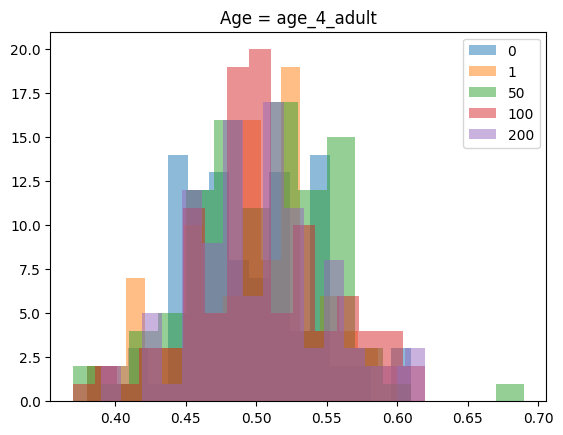

In [12]:
patient_chars = {
"Age": "age_4_adult", 
"Sex": "M",
"SD": "SD_2_normal",
"PA": "PA_2",
"Smoking": "sm_1_not_smoker",
"BMI": "bmi_2_normal",
"Alcohol": "low",
"Diabetes": "False",
"Hypertension": "False",
}

plot_histograms_count_distrib(net2, patient_chars)